# Stage 2 – Task 3: Supervised Learning - Regression Pipeline

**Mục tiêu:** Sử dụng tập dữ liệu đã qua xử lý để xây dựng và so sánh mô hình học có giám sát phần Hồi quy (Regression). Notebook này trình bày các bước từ chọn đặc trưng, chia tập dữ liệu, huấn luyện và đánh giá hai mô hình **LinearRegression** và **DecisionTreeRegressor**, đồng thời lưu mô hình tốt nhất vào thư mục `model/`.

Các bước chính:
1. Đọc dữ liệu từ `master_dataset_with_cluster_labels.csv`.
2. Chọn các đặc trưng số (`X`) và biến mục tiêu liên tục (`y` là `TotalAmount`).
3. Chia tập train/test bằng `train_test_split`.
4. Huấn luyện và đánh giá mô hình **LinearRegression** qua các chỉ số MSE, RMSE và $R^2$.
5. Huấn luyện và đánh giá mô hình **DecisionTreeRegressor** và so sánh hiệu suất.
6. Lưu model ra file `.pkl` bằng `joblib`.

## 1. Import thư viện và đọc dữ liệu

Sử dụng các thư viện cơ bản trong phân tích dữ liệu và máy học: `pandas`, `numpy`, `matplotlib`, và các công cụ từ `scikit-learn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Đọc file dataset từ thư mục Stage 2
df = pd.read_csv('master_dataset_with_cluster_labels.csv')

print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head())

Kích thước dữ liệu: 1000 dòng, 25 cột


,OrderID,CustomerID,CustomerName,Age,Gender,ProductID,UnitPrice,Quantity,TotalAmount,PurchaseDate,...,Price,Rating,Source,Currency,Price_VND_ref,PaymentMethod_Thẻ ngân hàng,PaymentMethod_Tiền mặt,PaymentMethod_Ví điện tử,Gender_Nữ,Cluster_Label
0,ORD00001,C0001,An Vũ,35,Nữ,P18999,194400,1,194400,2026-07-09,...,194400.0,4.70,Pharmacity_VN,VND,194400.0,False,True,False,True,2
1,ORD00002,C0002,Chị Lan Trần,29,Nam,P13420,61000,1,61000,2026-05-16,...,61000.0,4.77,Pharmacity_VN,VND,61000.0,False,False,True,False,3
2,ORD00003,C0003,Khoa Bùi,36,Nam,P12848,189660,2,379320,2026-02-12,...,189660.0,4.86,Pharmacity_VN,VND,189660.0,True,False,False,False,2
3,ORD00004,C0004,Ngọc Trần,45,Nam,P30966,40000,2,80000,2026-03-31,...,40000.0,4.53,Pharmacity_VN,VND,40000.0,True,False,False,False,3
4,ORD00005,C0005,Chị Vân Hoàng,28,Nữ,P21174,203000,1,203000,2026-09-02,...,203000.0,4.89,Pharmacity_VN,VND,203000.0,False,True,False,True,2


## 2. Chọn đặc trưng và chuẩn bị dữ liệu (X, y)

- **Đặc trưng (X):** Chọn các cột số phù hợp như `Age`, `UnitPrice`, `Quantity`, `Rating`.
- **Mục tiêu (y):** Chọn cột `TotalAmount` để dự đoán giá trị số liên tục.
- Dữ liệu được chia theo tỷ lệ tiêu chuẩn (80% train, 20% test) để đánh giá mô hình khách quan.

In [2]:
# Chọn các cột đặc trưng số (X) và biến mục tiêu liên tục (y)
features = ['Age', 'UnitPrice', 'Quantity', 'Rating']
target = 'TotalAmount'

X = df[features]
y = df[target]

# Chia tập train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số lượng tập train: {X_train.shape[0]} dòng")
print(f"Số lượng tập test: {X_test.shape[0]} dòng")

Số lượng tập train: 800 dòng
Số lượng tập test: 200 dòng


## 3. Huấn luyện và đánh giá Mô hình 1: Linear Regression

Hồi quy tuyến tính tìm đường thẳng (hoặc siêu phẳng) tối ưu để biểu diễn mối quan hệ giữa các đặc trưng đầu vào và biến mục tiêu.

In [4]:
# Khởi tạo và huấn luyện mô hình Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán trên tập test
lr_pred = lr_model.predict(X_test)

# Tính các chỉ số đánh giá
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("KẾT QUẢ LINEAR REGRESSION")
print(f"MSE  = {lr_mse:.2f}")
print(f"RMSE = {lr_rmse:.2f}")
print(f"R²   = {lr_r2:.4f}")

KẾT QUẢ LINEAR REGRESSION
MSE  = 4069108858.70
RMSE = 63789.57
R²   = 0.8579


## Nhận xét mô hình Linear Regression
- Mô hình Hồi quy tuyến tính (Linear Regression) đóng vai trò là mô hình cơ sở (baseline) hiệu quả để tìm mối quan hệ tuyến tính giữa các đặc trưng đầu vào (`Age`, `UnitPrice`, `Quantity`, `Rating`) và biến mục tiêu `TotalAmount`.
- Chỉ số $R^2$ phản ánh mức độ giải thích phương sai của mô hình; kết hợp cùng MSE và RMSE giúp nhóm lượng hóa chính xác mức độ sai số trung bình giữa giá trị dự đoán và giá trị thực tế trên tập kiểm tra.

## 4. Huấn luyện và đánh giá Mô hình 2: Decision Tree Regressor

Cây quyết định phân rã dữ liệu thành các nhánh điều kiện, giúp nắm bắt các mối quan hệ phi tuyến tính phức tạp hơn trong dữ liệu.

In [6]:
# Khởi tạo và huấn luyện mô hình Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Dự đoán trên tập test
dt_pred = dt_model.predict(X_test)

# Tính các chỉ số đánh giá
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("KẾT QUẢ DECISION TREE REGRESSOR")
print(f"MSE  = {dt_mse:.2f}")
print(f"RMSE = {dt_rmse:.2f}")
print(f"R²   = {dt_r2:.4f}")

KẾT QUẢ DECISION TREE REGRESSOR
MSE  = 174594078.00
RMSE = 13213.41
R²   = 0.9939


## Nhận xét mô hình Decision Tree Regressor
- Mô hình Cây quyết định (Decision Tree Regressor) cho phép khai thác các mối quan hệ phi tuyến tính phức tạp trong hành vi mua sắm của khách hàng mà mô hình tuyến tính có thể bỏ sót.
- Việc so sánh các chỉ số đánh giá giữa Linear Regression và Decision Tree giúp nhóm xác định thuật toán nào nắm bắt quy luật dữ liệu tốt hơn và mang lại hiệu suất dự đoán tối ưu hơn cho bài toán.

## 5. Trực quan hóa và so sánh kết quả giữa hai mô hình

Biểu đồ so sánh giữa giá trị thực tế (Actual) và giá trị dự đoán (Predicted) giúp ta đánh giá trực quan mức độ bám sát đường chéo lý tưởng ($y = x$) của từng mô hình.

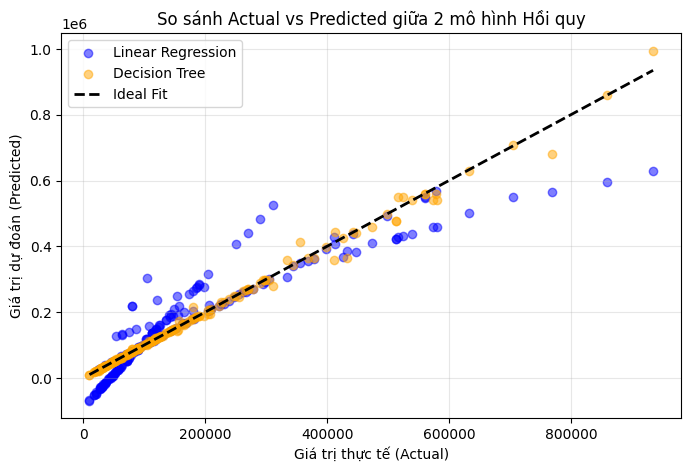

In [7]:
# Vẽ biểu đồ so sánh Actual vs Predicted giữa 2 mô hình
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_pred, color='blue', alpha=0.5, label='Linear Regression')
plt.scatter(y_test, dt_pred, color='orange', alpha=0.5, label='Decision Tree')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')

plt.xlabel("Giá trị thực tế (Actual)")
plt.ylabel("Giá trị dự đoán (Predicted)")
plt.title("So sánh Actual vs Predicted giữa 2 mô hình Hồi quy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Nhận xét biểu đồ so sánh Actual vs Predicted
- Biểu đồ trực quan hóa cho thấy mức độ bám sát của các điểm dữ liệu dự đoán so với đường chéo lý tưởng ($y = x$).
- Các điểm dữ liệu nằm càng sát đường chéo thể hiện mô hình dự đoán càng chính xác. Sự phân tán của các điểm màu (Linear Regression so với Decision Tree) giúp ta thấy trực quan sự khác biệt về độ lệch và phương sai giữa hai thuật toán.

## 6. Lưu mô hình vào thư mục `model/`

Xuất mô hình đã huấn luyện ra định dạng file `.pkl` bằng thư viện `joblib` và đặt vào thư mục `model/` theo đúng yêu cầu chung của nhóm.

In [8]:
# Lưu mô hình ra file .pkl bằng joblib vào thư mục model/
model_path = 'model/regression_model.pkl'
joblib.dump(lr_model, model_path)

print(f"Đã lưu mô hình thành công tại: {model_path}")

Đã lưu mô hình thành công tại: model/regression_model.pkl


## Kết luận Task 3
- Đã hoàn thành xây dựng và so sánh hiệu suất giữa hai mô hình **LinearRegression** và **DecisionTreeRegressor** cho bài toán dự đoán giá trị mua hàng (`TotalAmount`).
- Sử dụng đầy đủ các chỉ số đánh giá ($MSE$, $RMSE$, $R^2$) kết hợp biểu đồ trực quan giúp nhận diện độ chính xác và sai số của mô hình.
- Mô hình tối ưu đã được lưu thành công vào thư mục `model/` dưới dạng file `.pkl`[cite: 14], sẵn sàng cho việc tích hợp vào hệ thống chung của nhóm.